# Script 2 — Fine-Tuning Mistral-7B-Instruct · Venous Medicine
**Hardware:** RTX 5090 (32 GB VRAM) · **MLOps:** Weights & Biases

### Methods active in this notebook
| Goal | Method | Key flag |
|---|---|---|
| Faster training (2–2.7×) | **Unsloth** fused Triton kernels | `FastLanguageModel` |
| Memory + base compression | **QLoRA** 4-bit NF4 + double quant | `load_in_4bit=True` |
| Proper weight init | **PiSSA** SVD-based adapter init | `init_lora_weights="pissa"` |
| Better convergence | **DoRA** magnitude + direction decomp | `use_dora=True` |
| Stable high-rank gradients | **rsLoRA** `alpha/√r` scaling | `use_rslora=True` |
| Best adaptation quality | **All-linear** target modules | `target_modules="all-linear"` |
| Eliminate padding waste | **Packing** short sequences together | `packing=True` |

Run cells top-to-bottom. W&B dashboard opens after Cell 10 starts training.

In [3]:
import torch
print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Supported architectures: {torch.cuda.get_arch_list()}')

PyTorch 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
Supported architectures: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [5]:
# ── 0. Install dependencies ───────────────────────────────────────────────────
import subprocess, sys, platform

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

# PyTorch is pre-installed in venv. Only install extra deps.
pip('transformers>=4.40', 'datasets>=2.19', 'peft>=0.10', 'trl>=0.8',
    'bitsandbytes>=0.43', 'accelerate>=0.29', 'wandb>=0.17',
    'scipy', 'sentencepiece')

# Flash Attention 2 (RTX 5090 supports it; skip if build fails)
try:
    pip('flash-attn', '--no-build-isolation')
    FLASH_ATTN = True
    print('[INFO] Flash Attention 2 installed.')
except Exception as e:
    print(f'[INFO] flash-attn build failed ({e}) — continuing without it.')
    FLASH_ATTN = False

# Unsloth (requires Linux/WSL; native Windows falls back to PEFT)
try:
    pip('unsloth')
    print('[INFO] Unsloth installed.')
except Exception:
    print('[INFO] Unsloth install skipped — will use PEFT path.')

import torch
assert torch.cuda.is_available(), 'CUDA not available — check CUDA Toolkit installation'
print(f'PyTorch {torch.__version__} | CUDA {torch.version.cuda}')
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'OS   : {platform.system()}')

In [8]:
# ── 1. W&B login ──────────────────────────────────────────────────────────────
import wandb, os

wandb.login()   # first run: browser prompt; subsequent runs: cached key

WANDB_PROJECT  = 'mistral-venous-medicine'
WANDB_RUN_NAME = 'mistral7b-pissa-dora-rslora-unsloth-v1'
os.environ['WANDB_PROJECT'] = WANDB_PROJECT
print(f'W&B project: {WANDB_PROJECT}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/krish/.netrc.
wandb: Currently logged in as: claudekumar07 (claudekumar07-cygnus-medical) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: mistral-venous-medicine


In [30]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
from pathlib import Path

BASE_MODEL_ID    = 'mistralai/Mistral-7B-Instruct-v0.2'
TRAIN_FILE       = Path('training_data_train.jsonl')
VAL_FILE         = Path('training_data_val.jsonl')
OUTPUT_DIR       = Path('training_output')
LORA_ADAPTER_DIR = Path('lora_adapter')
MERGED_MODEL_DIR = Path('merged_model')

# ── Training hyperparameters
NUM_EPOCHS       = 3
BATCH_SIZE       = 4       # RTX 5090 32GB handles 4 comfortably with 4-bit
GRAD_ACCUM_STEPS = 4       # effective batch = 16
LEARNING_RATE    = 2e-4    # LoRA sweet-spot; cosine scheduler decays from here
MAX_SEQ_LENGTH   = 2048
WARMUP_RATIO     = 0.05
LR_SCHEDULER     = 'cosine'
SAVE_STEPS       = 100
EVAL_STEPS       = 100
LOGGING_STEPS    = 10
RANDOM_SEED      = 42

# ── LoRA / adapter config
LORA_R       = 32
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGET  = 'all-linear'

# ── Method flags
USE_DORA    = True
USE_RSLORA  = True
LORA_INIT   = 'pissa'

print('Config loaded.')
print(f'  r={LORA_R}, alpha={LORA_ALPHA}, init={LORA_INIT}, DoRA={USE_DORA}, rsLoRA={USE_RSLORA}')
print(f'  Target modules: {LORA_TARGET}')

Config loaded.
  r=32, alpha=32, init=pissa, DoRA=True, rsLoRA=True
  Target modules: all-linear


In [31]:
# ── 3. Load dataset ───────────────────────────────────────────────────────────
from datasets import load_dataset

ds = load_dataset('json',
                  data_files={'train': str(TRAIN_FILE), 'validation': str(VAL_FILE)})
print(ds)
print('\nSample (first 300 chars):')
print(ds['train'][0]['text'][:300], '...')

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 4007
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1002
    })
})

Sample (first 300 chars):
<s>[INST] You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.

What are the key clinical concepts described in the following passage?

push, easily seen w ...


In [12]:
! pip install psutil

In [13]:
! pip install flash_attn --no-build-isolation

  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)
  Preparing metadata (pyproject.toml) ... done
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
anceled
ERROR: Operation cancelled by user


In [16]:
! source ~/pytorch_env/bin/activate
! pip uninstall flash-attn -y
! pip install flash-attn --only-binary :all: --no-build-isolation

ERROR: Could not find a version that satisfies the requirement flash-attn (from versions: none)
ERROR: No matching distribution found for flash-attn


In [17]:
! pip install flash-attn==2.5.8 --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.1 MB/s  0:00:00 eta 0:00:01
  Preparing metadata (pyproject.toml) ... done
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
anceled
ERROR: Operation cancelled by user


In [9]:
# ── 4. Detect Unsloth availability and set runtime path ───────────────────────
USE_UNSLOTH = False
try:
    from unsloth import FastLanguageModel
    from unsloth.training_args import UnslothTrainingArguments
    USE_UNSLOTH = True
    print('Unsloth detected — using fused Triton kernels (2–2.7× faster).')
except ImportError:
    print('Unsloth not available — using standard PEFT + HuggingFace Trainer.')
    print('Training will be correct but without kernel-level speed boost.')

print(f'Runtime: {"Unsloth" if USE_UNSLOTH else "PEFT"}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth not available — using standard PEFT + HuggingFace Trainer.
Training will be correct but without kernel-level speed boost.
Runtime: PEFT


In [11]:
# ── 5. Load base model + tokenizer ───────────────────────────────────────────
import torch

if USE_UNSLOTH:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
        dtype=None,
        device_map='auto',
    )
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    #attn_impl = 'flash_attention_2' if FLASH_ATTN else 'eager'
    attn_impl = 'eager'
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
        torch_dtype=torch.bfloat16,
        attn_implementation=attn_impl,
    )
    model.config.use_cache = False
    model.config.pretraining_tp = 1

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

total_params = sum(p.numel() for p in model.parameters())
print(f'Base model loaded: {total_params / 1e9:.2f}B params')
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto"
)
print(f"Model loaded: {model.config.model_type}")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: mistral


In [6]:
# ── 6. Apply LoRA adapters: PiSSA + DoRA + rsLoRA + all-linear ────────────────
USE_UNSLOTH = False
if USE_UNSLOTH:
    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=RANDOM_SEED,
        use_dora=USE_DORA,
        use_rslora=USE_RSLORA,
        init_lora_weights=LORA_INIT,
    )
else:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        bias='none',
        task_type='CAUSAL_LM',
        use_dora=USE_DORA,
        use_rslora=USE_RSLORA,
        init_lora_weights=LORA_INIT,
    )
    model = get_peft_model(model, lora_config)
    model.enable_input_require_grads()

model.print_trainable_parameters()
print(f'\nMethod summary:')
print(f'  Init   : {LORA_INIT.upper()} (SVD-based, aligned with principal weight directions)')
print(f'  DoRA   : {USE_DORA} (magnitude + direction decomposition)')
print(f'  rsLoRA : {USE_RSLORA} (alpha/sqrt(r) = {LORA_ALPHA}/{LORA_R**0.5:.2f} ≈ {LORA_ALPHA/LORA_R**0.5:.2f})')
print(f'  Target : {LORA_TARGET}')

KeyboardInterrupt: 

In [7]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')
print(f'GPU memory total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2",
    dtype=torch.bfloat16,
    device_map="auto"
)
print(f'After model load - GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')

CUDA available: True
GPU memory free: 0.0 GB
GPU memory total: 34.2 GB


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


After model load - GPU memory free: 0.0 GB


In [1]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2",
    quantization_config=bnb_config,
    device_map="auto"
)

print(f'GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GPU memory free: 28.0 GB


In [5]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj'],
    bias='none',
    task_type='CAUSAL_LM',
    use_dora=True,
    use_rslora=True,
    init_lora_weights='gaussian',  # Works with quantized models
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 13,795,328 || all params: 7,255,527,424 || trainable%: 0.1901


In [10]:
# ── 7. Training arguments ─────────────────────────────────────────────────────
from transformers import TrainingArguments

USE_UNSLOTH = False
OPTIM = 'adamw_8bit' if USE_UNSLOTH else 'paged_adamw_32bit'
GC = not USE_UNSLOTH

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=GC,
    optim=OPTIM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    fp16=False,
    bf16=True,
    logging_steps=LOGGING_STEPS,
    eval_strategy='steps',
    eval_steps=EVAL_STEPS,
    save_strategy='steps',
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='wandb',
    run_name=WANDB_RUN_NAME,
    dataloader_pin_memory=True,
    seed=RANDOM_SEED,
)

eff_batch = BATCH_SIZE * GRAD_ACCUM_STEPS
steps_per_epoch = len(ds['train']) // eff_batch
print(f'Effective batch size : {eff_batch}')
print(f'Steps / epoch        : ~{steps_per_epoch}')
print(f'Optimizer            : {OPTIM}')
print(f'Gradient checkpointing: {"Unsloth" if USE_UNSLOTH else "HuggingFace"}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Effective batch size : 16
Steps / epoch        : ~250
Optimizer            : paged_adamw_32bit
Gradient checkpointing: HuggingFace


In [12]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.2")
tokenizer.pad_token = tokenizer.eos_token
print('Tokenizer loaded.')

Tokenizer loaded.


In [33]:
def tokenize_function_old(examples):
    outputs = tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        return_tensors=None,
        padding=False,
    )
    outputs['labels'] = outputs['input_ids'].copy()
    return outputs

def tokenize_fn(batch):
    result = tokenizer(
        batch['text'],
        truncation=True,
        max_length=512,
        padding='max_length',
        return_tensors=None,
    )
    result['labels'] = result['input_ids'].copy()
    return result

ds_train = ds['train'].map(tokenize_fn, batched=True, batch_size=64, remove_columns=['text'])
ds_val = ds['train'].map(tokenize_fn, batched=True, batch_size=64, remove_columns=['text'])

ds['train'] = ds['train'].map(tokenize_function, batched=True, remove_columns=['text'])
ds['validation'] = ds['validation'].map(tokenize_function, batched=True, remove_columns=['text'])

print(f'Dataset columns: {ds["train"].column_names}')
print(f'Train examples : {len(ds["train"]):,}')
print(f'Val   examples : {len(ds["validation"]):,}')

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

Dataset columns: ['input_ids', 'attention_mask', 'labels']
Train examples : 4,007
Val   examples : 1,002


In [34]:
# ── 8. SFT Trainer ────────────────────────────────────────────────────────────
from transformers import Trainer , DataCollatorForLanguageModeling
from datasets import load_dataset

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
)

print('Trainer ready.')
print(f'Train examples : {len(ds["train"]):,}')
print(f'Val   examples : {len(ds["validation"]):,}')

Trainer ready.
Train examples : 4,007
Val   examples : 1,002


In [26]:
# ── 9. Log hyperparameters to W&B before training starts ─────────────────────
wandb.init()
wandb.config.update({
    'base_model'      : BASE_MODEL_ID,
    'lora_r'          : LORA_R,
    'lora_alpha'      : LORA_ALPHA,
    'lora_dropout'    : LORA_DROPOUT,
    'lora_target'     : LORA_TARGET,
    'lora_init'       : LORA_INIT,
    'use_dora'        : USE_DORA,
    'use_rslora'      : USE_RSLORA,
    'effective_scale' : round(LORA_ALPHA / LORA_R**0.5, 4),
    'use_unsloth'     : USE_UNSLOTH,
    'quantization'    : '4-bit NF4 + double quant',
    'optimizer'       : OPTIM,
    'learning_rate'   : LEARNING_RATE,
    'epochs'          : NUM_EPOCHS,
    'batch_size_eff'  : BATCH_SIZE * GRAD_ACCUM_STEPS,
    'max_seq_length'  : MAX_SEQ_LENGTH,
    'packing'         : True,
    'train_examples'  : len(ds['train']),
    'val_examples'    : len(ds['validation']),
})
print('Hyperparameters logged to W&B.')

train/epoch,▁█
train/global_step,▁█
train/grad_norm,▁█
train/learning_rate,▁█
train/loss,█▁
train/epoch,0.07984
train/global_step,20
train/grad_norm,2.50972
train/learning_rate,0.0001
train/loss,1.72627


Hyperparameters logged to W&B.


In [35]:
# ── 10. Train ─────────────────────────────────────────────────────────────────
train_result = trainer.train()

print('\n=== Training complete ===')
print(f'Final train loss : {train_result.training_loss:.4f}')
print(f'Total steps      : {train_result.global_step}')

wandb.log({'train/final_loss': train_result.training_loss,   
           'train/total_steps': train_result.global_step}) 

Step,Training Loss,Validation Loss
100,1.491097,1.434338
200,1.510050,1.343578
300,1.279522,1.260203
400,1.334155,1.199960
500,1.272039,1.141805
600,1.128412,1.089354
700,1.154405,1.073470
753,1.159537,1.072645



=== Training complete ===
Final train loss : 1.3106
Total steps      : 753


In [37]:
import math

# Get final metrics from training
final_metrics = trainer.state.best_model_checkpoint  # or trainer.state.log_history[-1]

# Or just evaluate without callbacks
from torch.utils.data import DataLoader

eval_dataloader = DataLoader(ds_val, batch_size=4)
model.eval()
total_loss = 0
with torch.no_grad():
    for batch in eval_dataloader:
        batch = {k: v.to('cuda') for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

val_loss = total_loss / len(eval_dataloader)
perplexity = math.exp(val_loss)

print(f'Validation loss       : {val_loss:.4f}')
print(f'Validation perplexity : {perplexity:.2f}')

AttributeError: 'list' object has no attribute 'to'

In [41]:
# Get final training loss (find last training step)
train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
final_train_loss = train_losses[-1] if train_losses else None

print(f'Final training loss        : {final_train_loss:.4f}')

print('\n=== TRAINING COMPLETE ===')
print(f'Validation loss       : {best_eval_loss:.4f}')
print(f'Validation perplexity : {perplexity:.2f}')
print(f'Model converged well on medical domain data')

Final training loss        : 1.1595

=== TRAINING COMPLETE ===
Validation loss       : 1.0726
Validation perplexity : 2.92
Model converged well on medical domain data


In [43]:
import torch

model.eval()
correct_tokens, total_tokens = 0, 0
n_samples = min(200, len(ds_val))

with torch.no_grad():
    for i in range(n_samples):
        input_ids = torch.tensor(ds_val[i]['input_ids']).unsqueeze(0).to(model.device)
        labels = input_ids.clone()
        
        outputs = model(input_ids=input_ids, labels=labels)
        logits = outputs.logits[:, :-1, :]
        targets = labels[:, 1:]
        
        preds = logits.argmax(dim=-1)
        mask = targets != tokenizer.pad_token_id
        
        correct_tokens += (preds == targets)[mask].sum().item()
        total_tokens += mask.sum().item()

token_accuracy = correct_tokens / total_tokens if total_tokens else 0.0
print(f'Token-level accuracy ({n_samples} val samples): {token_accuracy:.4f} ({token_accuracy*100:.2f}%)')

Token-level accuracy (200 val samples): 0.7331 (73.31%)


In [44]:
# ── 13. Save LoRA adapter ─────────────────────────────────────────────────────
LORA_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

if USE_UNSLOTH:
    model.save_pretrained(str(LORA_ADAPTER_DIR))
    tokenizer.save_pretrained(str(LORA_ADAPTER_DIR))
else:
    trainer.model.save_pretrained(str(LORA_ADAPTER_DIR))
    tokenizer.save_pretrained(str(LORA_ADAPTER_DIR))

print(f'LoRA adapter (PiSSA + DoRA + rsLoRA) saved → {LORA_ADAPTER_DIR}')

LoRA adapter (PiSSA + DoRA + rsLoRA) saved → lora_adapter


In [45]:
# ── 14. Merge LoRA into base model and save ───────────────────────────────────
MERGED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if USE_UNSLOTH:
    model.save_pretrained_merged(
        str(MERGED_MODEL_DIR),
        tokenizer,
        save_method='merged_16bit',
    )
else:
    import torch
    from peft import PeftModel
    from transformers import AutoModelForCausalLM

    print('Loading base model in fp16 for merge (no quantisation)...')
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto',
    )
    print('Merging...')
    merged = PeftModel.from_pretrained(base, str(LORA_ADAPTER_DIR))
    merged = merged.merge_and_unload()
    merged.save_pretrained(str(MERGED_MODEL_DIR), safe_serialization=True)
    tokenizer.save_pretrained(str(MERGED_MODEL_DIR))

print(f'Merged model saved → {MERGED_MODEL_DIR.resolve()}')

Loading base model in fp16 for merge (no quantisation)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Merging...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved → /home/krish/finetuning/venv_pytorch/Include/merged_model


In [48]:
# ── 15. Finalise W&B run ──────────────────────────────────────────────────────
wandb.summary.update({
    'base_model'          : BASE_MODEL_ID,
    'lora_r'              : LORA_R,
    'lora_alpha'          : LORA_ALPHA,
    'lora_init'           : LORA_INIT,
    'use_dora'            : USE_DORA,
    'use_rslora'          : USE_RSLORA,
    'rslora_effective_scale': round(LORA_ALPHA / LORA_R**0.5, 4),
    'use_unsloth'         : USE_UNSLOTH,
    'train_loss'          : train_result.training_loss,
    'val_loss'            : val_loss,
    'val_perplexity'      : perplexity,
    'val_token_accuracy'  : token_accuracy,
    'epochs'              : NUM_EPOCHS,
    'merged_model_path'   : str(MERGED_MODEL_DIR.resolve()),
})
wandb.finish()

print('=== All done ===')
print(f'W&B run finished. Dashboard: https://wandb.ai/{wandb.run.entity}/{WANDB_PROJECT}')
print(f'Merged model : {MERGED_MODEL_DIR.resolve()}')
print(f'LoRA adapter : {LORA_ADAPTER_DIR.resolve()}')

In [47]:
# ── 15. Finalise W&B run ──────────────────────────────────────────────────────
wandb.summary.update({
    'base_model'          : 'mistralai/Mistral-7B-Instruct-v0.2',
    'lora_r'              : 32,
    'lora_alpha'          : 32,
    'lora_init'           : 'gaussian',
    'use_dora'            : True,
    'use_rslora'          : True,
    'rslora_effective_scale': round(32 / 32**0.5, 4),
    'use_unsloth'         : False,
    'train_loss'          : final_train_loss,
    'val_loss'            : best_eval_loss,
    'val_perplexity'      : perplexity,
    'val_token_accuracy'  : token_accuracy,
    'epochs'              : 3,
    'merged_model_path'   : '/home/krish/finetuning/venv_pytorch/Include/merged_model',
})
wandb.finish()

print('=== All done ===')
print(f'Merged model saved')
print(f'W&B run finalized')

eval/loss,█▆▅▃▂▁▁▁▇
eval/runtime,████████▁
eval/samples_per_second,█▃▂▃▃█▅▃▁
eval/steps_per_second,▇▂▁▂▂█▄▃▁
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train/final_loss,▁
train/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇████
train/grad_norm,▅▇▅█▇▆▂▂▂▂▂▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
train/learning_rate,▃▆███████▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
train/loss,▇▄▃▆█▇▇▆▇▆▆▇▇▆▆▅▅▄▄▅▄▄▄▄▄▃▄▄▄▂▁▂▂▂▁▂▂▂▂▂
+1,...


=== All done ===
Merged model saved
W&B run finalized


In [49]:
#Testing the model 
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load merged model
model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/finetuning/venv_pytorch/Include/merged_model',
    dtype=torch.bfloat16,
    device_map='auto'
)
tokenizer = AutoTokenizer.from_pretrained('/home/krish/finetuning/venv_pytorch/Include/merged_model')

def generate_response(prompt, max_length=200):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test prompts
prompts = [
    "There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?",
    "SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary refluxes back to the femoral system. What is the shunt type and the suitable ligation for that shunt?",
    "There's a perforator at the Hunterian level feeding the GSV with reflux into tributaries. The SFJ is competent. No direct deep-to-GSV entry. What is the shunt type here and how do I ligate this?",
]

for prompt in prompts:
    print(f'\n{"="*70}')
    print(f'PROMPT: {prompt}')
    print(f'{"="*70}')
    response = generate_response(prompt)
    print(f'RESPONSE:\n{response}')

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.



PROMPT: There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?
RESPONSE:
There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?

Answer: This is a type III shunt. The treatment is to ligate the GSV at the level of the saphenofemoral junction. The proximal stump should be tied and divided.

PROMPT: SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary refluxes back to the femoral system. What is the shunt type and the suitable ligation for that shunt?
RESPONSE:
SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary re

In [51]:
test_cases = {
    "Type 1": "Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?",
    
    "Type 2A": "Saphenofemoral junction is competent. The greater saphenous vein has entry from the femoral vein at mid-thigh level through a large tributary. Reflux present in this tributary and GSV below entry point. Deep veins normal. What shunt type and ligation?",
    
    "Type 2B": "SFJ is competent. A large perforating vein at Hunterian level connects femoral vein to GSV with significant reflux. GSV distal to entry shows retrograde flow into tributaries. No deep system involvement. Classify and recommend ligation.",
    
    "Type 2C": "SFJ competent. A medial thigh perforator feeds the GSV at mid-calf level with reflux propagating both proximally and distally. Associated tributary incompetence. What is this shunt type and management?",
    
    "Type 1+2": "SFJ incompetent with proximal GSV reflux. Additionally, mid-thigh perforator feeds GSV with secondary reflux into tributaries distally. Dual entry points. Classify and suggest complete ligation strategy.",
    
    "Type 3": "Incompetent calf perforators between gastrocnemius and soleus muscles communicating directly with deep posterior tibial veins. Bidirectional flow with reflux during calf compression. No superficial entry points. What type and approach?",
    
    "Type 4": "Pelvic venous insufficiency with ovarian/gonadal vein reflux crossing midline and draining via broad ligament veins into superficial system. SFJ competent. Lower abdominal symptoms with leg symptoms. Type and management?",
    
    "Type 5": "Laparoscopic findings: incompetent retroperitoneal veins draining into pelvic vasculature with secondary superficial reflux. Patent foramen ovale anatomy involved. Type classification?",
    
    "Type 6": "Direct reentry point: GSV incompetence with ectopic branch entering lateral femoral vein below SFJ. Reflux pattern unusual with entry below anatomic SFJ. Type and ligation site?",

    "No shunt": "Patient with normal duplex findings. Saphenofemoral junction is fully competent with no reflux. Greater saphenous vein shows normal antegrade flow during compression. No perforator incompetence. Deep veins patent with normal flow dynamics. All valves functioning properly. What is the diagnosis and recommended management?"
}

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/finetuning/venv_pytorch/Include/merged_model',
    dtype=torch.bfloat16,
    device_map='auto'
)
tokenizer = AutoTokenizer.from_pretrained('/home/krish/finetuning/venv_pytorch/Include/merged_model')

def answer_case(case_description):
    prompt = f"""Clinical Venous Case:
{case_description}

Provide:
1. Shunt type classification
2. Recommended ligation site(s)
3. Brief rationale

Answer:"""
    
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        max_length=300,
        temperature=0,
        top_p=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run tests
for shunt_type, case in test_cases.items():
    print(f'\n{"="*80}')
    print(f'SHUNT TYPE: {shunt_type}')
    print(f'{"="*80}')
    print(f'CASE:\n{case}\n')
    print(f'MODEL ANSWER:')
    response = answer_case(case)
    print(response)
    print()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



SHUNT TYPE: Type 1
CASE:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

MODEL ANSWER:
Clinical Venous Case:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

Provide:
1. Shunt type classification
2. Recommended ligation site(s)
3. Brief rationale

Answer:
1. Shunt type 3:
The reflux originates at the SFJ and descends along the GSV. The reflux then enters a tributary, which is the re-entry point for the recirculation. The recirculation is closed by the deep vein through the tributary.
The recommended ligation site is at the SFJ and the tributary.
The rationale is that the tributary is the re-entry point for the recirculation and therefore the ligation at the SFJ will interrupt the r

In [52]:
CHIVA_RULES = """
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

═══════════════════════════════════════════════════════════
CRITICAL RULE — SFJ COMPETENCE (read before classifying):
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perforator — SFJ REMAINS COMPETENT.
    This is true regardless of posYRatio or step label. Even posYRatio=0.05 with step=SFJ-Knee
    is a perforator entry if the clip reads EP N2→N2, NOT EP N1→N2.
═══════════════════════════════════════════════════════════

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT → go to Case A or B.
    NO  → SFJ COMPETENT → go to Case C.

─────────────────────────────────────────────────────────
Case A — EP N1→N2 EXISTS (SFJ or Hunterian), NO EP N2→N3
─────────────────────────────────────────────────────────
    If RP N2→N1 present AND no RP at N3 (no RP N3→N2, no RP N3→N1) → TYPE 1
    Ligation: Ligate at SFJ (y≤0.098) or Hunterian (y≤0.353).
            If multiple RP N2→N1: ligate below each except the most distal.

─────────────────────────────────────────────────────────
Case B — EP N1→N2 EXISTS (SFJ or Hunterian) AND EP N2→N3 EXISTS
─────────────────────────────────────────────────────────
    B1: RP N3→N2 or RP N3→N1, NO RP N2→N1               → TYPE 3
    B2: RP N3→N2 AND RP N2→N1                             → TYPE 3
    B3: RP N3→N1 AND RP N2→N1, eliminationTest absent    → UNDETERMINED (set needs_elim_test=true)
    B4: RP N3→N1 AND RP N2→N1, eliminationTest="Reflux"  → TYPE 1+2
    B5: RP N3→N1 AND RP N2→N1, eliminationTest="No Reflux" → TYPE 3

    TYPE 3 Ligation:
        Single RP at N3: Ligate EP at N2→N3. Follow up 6–12 months; if N2 reflux develops, ligate SFJ.
        Multiple RP at N3: Ligate every refluxing tributary at N2 junction (CHIVA 2 step 1). Same follow-up.

    TYPE 1+2 Ligation — depends on RP N2→N1 calibre:
        Small RP N2→N1: Apply CHIVA 2 (ligate EP N2→N3 first, then SFJ/Hunterian).
                        OR ligate SFJ first + all tributaries except one; once N2 normalises ligate last.
        Large / multiple RP N2→N1: Ligate SFJ/Hunterian + every refluxing tributary simultaneously.
                                    Ligate below each RP N2→N1 except the most distal.

─────────────────────────────────────────────────────────
Case C — NO EP N1→N2 ANYWHERE (SFJ COMPETENT)
─────────────────────────────────────────────────────────
    C-Sub-check: what type of EP clip exists?

    ── TYPE 2A ── EP N2→N3 present, NO EP N1→N2
        The defining feature is EP N2→N3 (GSV feeding a tributary) without any SFJ entry.
        RP may or may not be present in early/developing cases.
        Typical pattern: EP N2→N3 + RP N3→N2 or N3→N1. No RP N2→N1.
        Key signal: EP N2→N3 clip exists + NO EP N1→N2 clip exists anywhere.
        If multiple RP at N3 → set ask_branching=true (need calibre/distance/drainage info).
        Ligation: Ligate highest EP at N2→N3 junction.
                    If multiple branching at N3: ligate based on calibre, distance to perforator, drainage.

    ── TYPE 2B ── EP N2→N2 present, NO EP N1→N2, RP at N3, NO RP N2→N1
        Entry is via perforator (fromType=N2, toType=N2 — NOT N1→N2).
        IMPORTANT: EP N2→N2 at ANY posYRatio (even 0.05, SFJ-Knee step) = perforator, NOT SFJ.
        Key signal: EP N2→N2 clip + RP N3→N2 or N3→N1 + NO EP N1→N2 + NO RP N2→N1.
        If multiple RP at N3 → set ask_branching=true.
        Ligation: Ligate the highest EP N2→N2 (perforator entry point).

    ── TYPE 2C ── EP N2→N2 present, NO EP N1→N2, RP at N3, RP N2→N1 ALSO present
        Perforator entry (EP N2→N2) with secondary GSV reflux (RP N2→N1). SFJ still competent.
        IMPORTANT: 2C has EP N2→N2 (perforator), while Type 1+2 has EP N1→N2 (SFJ entry).
        If NO EP N1→N2 but RP N2→N1 exists with EP N2→N2 → TYPE 2C, not Type 1+2.
        Key signal: EP N2→N2 + RP N3 + RP N2→N1 + NO EP N1→N2.
        Ligation: Ligate perforator entry (highest EP N2→N2) AND all RP N2→N1 sites along GSV.

    Case C — NO SHUNT:
        If EP N2→N2 exists but NO RP clips of any kind → NO SHUNT DETECTED.

─────────────────────────────────────────────────────────
Case D — No RP in any clip → NO SHUNT DETECTED. No ligation needed.
─────────────────────────────────────────────────────────

QUICK DECISION TABLE (commit this to memory):
    Has EP N1→N2? YES + no EP N2→N3 + RP N2→N1           → TYPE 1
    Has EP N1→N2? YES + EP N2→N3 + RP N3 only             → TYPE 3
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + eliminationTest absent → UNDETERMINED
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="Reflux"          → TYPE 1+2
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="No Reflux"       → TYPE 3
    No EP N1→N2  + EP N2→N3                                → TYPE 2A
    No EP N1→N2  + EP N2→N2 + RP N3 + NO RP N2→N1         → TYPE 2B
    No EP N1→N2  + EP N2→N2 + RP N3 + RP N2→N1            → TYPE 2C
    No EP N1→N2  + EP N2→N2 + NO RP                        → NO SHUNT
    EP N1→N3 + RP N2→N1                                    → TYPE 4
    EP N1→N3 + RP N3→N2 or RP N3→N1                         → TYPE 5
    No RP at all                                            → NO SHUNT

CONCRETE EXAMPLES (match these patterns exactly):
    Type 1:  [EP N1→N2 y=0.06 SFJ-ENTRY, RP N2→N1 y=0.25]
            → EP N1→N2 present, RP N2→N1, no EP N2→N3, no N3 reflux → TYPE 1
    Type 2A: [EP N2→N3 y=0.20]  OR  [EP N2→N3 y=0.20, RP N3→N2 y=0.47]
            → No EP N1→N2, EP N2→N3 present → TYPE 2A
    Type 2B: [EP N2→N2 y=0.050 step=SFJ-Knee ligation-point-marker, RP N3→N1 y=0.132]
            → No EP N1→N2, EP N2→N2 = perforator, RP N3 only → TYPE 2B
    Type 2C: [EP N2→N2 y=0.050 step=SFJ-Knee ligation-point-marker, RP N3→N1 y=0.132, RP N2→N1 y=0.212]
            → No EP N1→N2, EP N2→N2 = perforator, RP N3 + RP N2→N1 → TYPE 2C
    Type 3:  [EP N1→N2 y=0.05 SFJ-ENTRY, EP N2→N3 y=0.132 ligation-point-marker, RP N3→N1 y=0.212]
            → EP N1→N2 + EP N2→N3 + RP N3→N1, no RP N2→N1 → TYPE 3
        Type 4:  [EP N1→N3 y=0.60, RP N2→N1 y=0.40]
            → EP N1→N3 with N2 return → TYPE 4
        Type 5:  [EP N1→N3 y=0.65, RP N3→N2 y=0.50, RP N3→N1 y=0.75]
            → EP N1→N3 with looping N3 return → TYPE 5
    Type 3 variant 2 (no elim test):
            [EP N1→N2, EP N2→N3, RP N3→N1, RP N2→N1, no eliminationTest] → UNDETERMINED
    Type 1+2:[EP N1→N2, EP N2→N3 eliminationTest="Reflux", RP N3→N1, RP N2→N1] → TYPE 1+2
    No shunt:[EP N1→N2 only, no RP]  OR  [EP N2→N2 only, no RP] → NO SHUNT

TYPE 2 BRANCHING — ask_branching flag:
    Set ask_branching=true when there are MULTIPLE RP at N3 tributaries in a Type 2A, 2B, or 2C case.
    The ligation choice among multiple N3 branches depends on:
        • Calibre of branches (equal or unequal)
        • Distance of each branch to its perforator
        • Whether drainage through the thinner vessel is possible
    If unequal calibre with drainage possible → ligate the larger vessel.
    If unequal calibre, no drainage → ligate the smaller vessel.
    If equal calibre, unequal distance → ligate the branch with longer distance to perforator.

COORDINATE HINTS (secondary — always check fromType/toType first):
    posYRatio ≤ 0.098   = SFJ region (upper thigh)
    0.099–0.353         = Hunterian / mid-thigh
    0.354–0.60          = Knee / popliteal
    > 0.60              = Calf / ankle (SPJ region for posterior clips)

OUTPUT FLAGS:
    needs_elim_test : true when RP N3→N1 + RP N2→N1 present but eliminationTest is absent (B3)
    ask_branching   : true for Type 2A/2B/2C with multiple RP at N3

CONFIDENCE GUIDE:
    Clear single pattern, no ambiguity         → 0.90–0.97
    Pattern present but some noise clips       → 0.80–0.89
    Ambiguous (needs elimination test)         → 0.50–0.65
    No pattern / insufficient clips            → 0.40–0.55
"""

In [56]:
prompt_v1 = f"""{CHIVA_RULES}
You are supposed to perform 2 tasks i.e. Shunt Classification and Appropriate Ligation 
=== ASSESSMENT: ===

═══════════════════════════════════════════════════════════════
STEP-BY-STEP DECISION GUIDE (Follow in order)
═══════════════════════════════════════════════════════════════

STEP 1: CHECK FOR EP N1→N2 (SFJ or Hunterian ENTRY)
    Look for: "EP N1→N2" with y≤0.098 (SFJ) or y≤0.353 (Hunterian)
    If YES with SFJ-ENTRY/Hunterian-ENTRY label → SFJ INCOMPETENT
    If NO  → SFJ COMPETENT (go to Case C)
    ✓ Found EP N1→N2? YES/NO

    STEP 2: IF YES to EP N1→N2, CHECK FOR REFLUX PATTERNS
    2a) ANY RP N3→N2 or RP N3→N1? (tributary reflux)
    2b) ANY RP N2→N1? (GSV reflux)
    2c) ANY RP anywhere else?
    2d) ANY EP N2→N3? (extra antegrade to tributary)

STEP 3: MATCH PATTERN TO TYPE

    ┌─ SFJ INCOMPETENT PATH (has EP N1→N2):
    │
    ├─ NO EP N2→N3:
    │  └─ Has RP N2→N1, no RP at N3 → TYPE 1 (confidence 0.90)
    │
    └─ YES EP N2→N3 EXISTS:
        ├─ Has RP N3 (at N2 or N1), NO RP N2→N1 → TYPE 3 (confidence 0.88)
        ├─ Has RP N3 AND RP N2→N1:
        │  ├─ eliminationTest absent → UNDETERMINED (confidence 0.55) [needs_elim_test=true]
        │  ├─ eliminationTest="Reflux" → TYPE 1+2 (confidence 0.80) 
        │  └─ eliminationTest="No Reflux" → TYPE 3 (confidence 0.75)

    ┌─ SFJ COMPETENT PATH (NO EP N1→N2):
    │
    ├─ EP N2→N3 EXISTS:
    │  └─ TYPE 2A (confidence 0.85-0.92)
    │     └─ Multiple RP at N3? → [ask_branching=true]
    │
    └─ ONLY EP N2→N2 (perforator entry):
        ├─ Has RP N3, NO RP N2→N1 → TYPE 2B (confidence 0.84)
        │  └─ Multiple RP at N3? → [ask_branching=true]
        ├─ Has RP N3 AND RP N2→N1 → TYPE 2C (confidence 0.82)
        │  └─ Multiple RP at N3? → [ask_branching=true]
        └─ No RP at all → NO SHUNT (confidence 0.95)

STEP 4: ASSIGN CONFIDENCE
    Clear pattern, no ambiguity → 0.90–0.97
    Pattern present, minor noise → 0.80–0.89
    Ambiguous / needs elimination test → 0.50–0.65
    Insufficient clips → 0.40–0.55

═══════════════════════════════════════════════════════════════
CRITICAL REMINDERS:
    • EP N1→N2 is THE KEY decision point — check this FIRST
    • EP N2→N2 means perforator (SFJ COMPETENT), never confuse with N1→N2
    • Type 2A has EP N2→N3; Type 2B/2C have EP N2→N2 (NOT N2→N3)
    • Type 2C differs from Type 1+2: 2C has EP N2→N2, Type 1+2 has EP N1→N2
    • Type 4/5 are N1→N3 path shunts and should be classified explicitly when present
    • RP only at N3 (not N2→N1) + EP N1→N2 = TYPE 3 (not 1+2)
═══════════════════════════════════════════════════════════════

=== TASK  ===
Follow the Step-by-Step Decision Guide above. 
Now remember the shunt type

=== LIGATION PLANNING FOR VENOUS SHUNT CLASSIFICATION ===

You are an expert vascular surgeon trained in CHIVA (hemodynamic conservative surgery) principles.
Your task is to generate a detailed, evidence-based ligation plan based on the shunt type and clinical findings.

=== SHUNT TYPE IDENTIFIED ===
Type: Shunt Type you classified in previous task


=== TASK ===
Based on the shunt type shunt_type, the clinical findings above, and the medical knowledge base provided:

1. Generate a detailed ligation plan with specific steps
2. Identify any additional clinical information needed
3. Consider complications and contraindications
4. Provide follow-up and monitoring recommendations
5. Consider CHIVA principles (hemodynamic, saphenous-vein-sparing when appropriate)

Important formatting rules:
1. ligation_steps must be a JSON array with one clear action per item.
2. Each ligation step must name the ligation point or vessel segment explicitly.
3. clinical_rationale must explain why that plan fits the shunt anatomy.
4. additional_info_needed must be [] when there is no meaningful extra information to request.
5. chiva_approach must describe the hemodynamic CHIVA reasoning, even if brief.

Output ONLY the Shunt Type and Ligation in the following format :
1. Type : ...
2. Ligation : ...
}}
}}"""

In [60]:
test_cases = {
    "Type 1": "Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?",
    
    "Type 2A": "Saphenofemoral junction is competent. The greater saphenous vein has entry from the femoral vein at mid-thigh level through a large tributary. Reflux present in this tributary and GSV below entry point. Deep veins normal. What shunt type and ligation?",
}
other_cases = {
    "Type 2B": "SFJ is competent. A large perforating vein at Hunterian level connects femoral vein to GSV with significant reflux. GSV distal to entry shows retrograde flow into tributaries. No deep system involvement. Classify and recommend ligation.",
    
    "Type 2C": "SFJ competent. A medial thigh perforator feeds the GSV at mid-calf level with reflux propagating both proximally and distally. Associated tributary incompetence. What is this shunt type and management?",
    
    "Type 1+2": "SFJ incompetent with proximal GSV reflux. Additionally, mid-thigh perforator feeds GSV with secondary reflux into tributaries distally. Dual entry points. Classify and suggest complete ligation strategy.",
    
    "Type 3": "Incompetent calf perforators between gastrocnemius and soleus muscles communicating directly with deep posterior tibial veins. Bidirectional flow with reflux during calf compression. No superficial entry points. What type and approach?",
    
    "Type 4": "Pelvic venous insufficiency with ovarian/gonadal vein reflux crossing midline and draining via broad ligament veins into superficial system. SFJ competent. Lower abdominal symptoms with leg symptoms. Type and management?",
    
    "Type 5": "Laparoscopic findings: incompetent retroperitoneal veins draining into pelvic vasculature with secondary superficial reflux. Patent foramen ovale anatomy involved. Type classification?",
    
    "Type 6": "Direct reentry point: GSV incompetence with ectopic branch entering lateral femoral vein below SFJ. Reflux pattern unusual with entry below anatomic SFJ. Type and ligation site?",

    "No shunt": "Patient with normal duplex findings. Saphenofemoral junction is fully competent with no reflux. Greater saphenous vein shows normal antegrade flow during compression. No perforator incompetence. Deep veins patent with normal flow dynamics. All valves functioning properly. What is the diagnosis and recommended management?"
}


def answer_case(case_description):
    prompt = prompt_v1
    
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        #max_length=300,
        temperature=0.8,
        top_p=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run tests
for shunt_type, case in test_cases.items():
    print(f'\n{"="*80}')
    print(f'SHUNT TYPE: {shunt_type}')
    print(f'{"="*80}')
    print(f'CASE:\n{case}\n')
    print(f'MODEL ANSWER:')
    response = answer_case(case)
    print(response)
    print()


SHUNT TYPE: Type 1
CASE:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

MODEL ANSWER:

=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

═══════════════════════════════════════════════════════════
CRITICAL RULE — SFJ COMPETENCE (read before classifying):
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perf

# Script 2 — Fine-Tuning Mistral-7B-Instruct · Venous Medicine
Retraining to make the model more specific to shunt classification and ligation

In [73]:
"""
PASTE THIS INTO A JUPYTER CELL IN YOUR NOTEBOOK
This trains the already fine-tuned model on reasoning tasks
"""

import sys
import os

# Add Windows path (accessible via WSL2 mount) to Python path
wsl_path = "/mnt/c/Users/Krish/Downloads/LLM_Finetuning"
sys.path.insert(0, wsl_path)
os.chdir(wsl_path)

print(f"Working directory: {os.getcwd()}")
print(f"Files in directory: {[f for f in os.listdir('.') if f.startswith('training_')]}")

# ============================================================================
# STEP 1: IMPORT AND LOAD DATA
# ============================================================================

from training_data_comprehensive import generate_comprehensive_training_pairs
from datasets import Dataset
import numpy as np

# Generate training data
training_pairs = generate_comprehensive_training_pairs()
print(f"Generated {len(training_pairs)} training pairs")

# Split into train/eval
np.random.seed(42)
indices = np.random.permutation(len(training_pairs))
train_size = int(0.8 * len(training_pairs))
train_indices = indices[:train_size]
eval_indices = indices[train_size:]

train_data = [training_pairs[i] for i in train_indices]
eval_data = [training_pairs[i] for i in eval_indices]

train_dataset = Dataset.from_dict({
    "text": [ex["text"] for ex in train_data],
})

eval_dataset = Dataset.from_dict({
    "text": [ex["text"] for ex in eval_data],
})

print(f"Training pairs: {len(train_dataset)}")
print(f"Eval pairs: {len(eval_dataset)}")

# ============================================================================
# STEP 2: SETUP TRAINING (assumes model, tokenizer already loaded)
# ============================================================================

from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from pathlib import Path

output_dir = "./reasoning_finetuned_output"
Path(output_dir).mkdir(exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    warmup_steps=5,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    logging_steps=1,
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=False,
    max_grad_norm=1.0,
    seed=42,
    bf16=True,
    optim="paged_adamw_32bit",
    gradient_checkpointing=True,
)

# ============================================================================
# STEP 3: TOKENIZE DATA AND CREATE TRAINER
# ============================================================================

# Note: tokenizer should already be loaded in your notebook from the cell where you loaded the model

# Tokenize the datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
eval_dataset_tokenized = eval_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Data collator for language modeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_tokenized,
    data_collator=data_collator,
)

print("Starting training...")
train_result = trainer.train()

print(f"\nTraining completed!")
print(f"Final training loss: {train_result.training_loss:.4f}")

# ============================================================================
# STEP 4: SAVE REFINED MODEL
# ============================================================================

final_output_dir = "./mistral_reasoning_enhanced"
Path(final_output_dir).mkdir(exist_ok=True)

model.save_pretrained(final_output_dir)
tokenizer.save_pretrained(final_output_dir)

print(f"✓ Model saved to {final_output_dir}")

# ============================================================================
# STEP 5: QUICK TEST ON NEW CASE
# ============================================================================

print("\n" + "="*80)
print("QUICK INFERENCE TEST")
print("="*80)

test_prompt = """[INST] === SHUNT CLASSIFICATION ===
Clips:
  Clip 00: EP N1→N2  y=0.080 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: RP N2→N1  y=0.300 [GSV-TRUNK-REFLUX: N2→N1]

Classify using CHIVA rules. Provide type, confidence, and reasoning. [/INST]"""

inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=250, temperature=0.3, top_p=0.9)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

if "[/INST]" in response:
    response = response.split("[/INST]")[1].strip()

print("Test Response:")
print(response)

Working directory: /mnt/c/Users/Krish/Downloads/LLM_Finetuning
Files in directory: ['training_cell.py', 'training_data_comprehensive.py', 'training_data_reasoning.py']
Generated 17 training pairs
Training pairs: 13
Eval pairs: 4


Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training...


OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 44.86 GiB is allocated by PyTorch, and 287.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import shutil
import os

src = '/home/krish/finetuning/venv_pytorch/Include'
dst = '/mnt/c/Users/Krish/Downloads/LLM_Finetuning/Include_backup'

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✓ Copied entire Include folder to Windows")
print(f"Location: C:\\Users\\Krish\\Downloads\\LLM_Finetuning\\Include_backup")


# Training Everything from beginning to suit our task
Retraining to make the model more specific to shunt classification and ligation

In [14]:
! pip3 install --force-reinstall --no-deps --pre torch --index-url https://download.pytorch.org/whl/nightly/cu121

Looking in indexes: https://download.pytorch.org/whl/nightly/cu121
  Using cached https://download.pytorch.org/whl/nightly/cu121/torch-2.6.0.dev20241112%2Bcu121-cp313-cp313-linux_x86_64.whl (767.9 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0
    Uninstalling torch-2.11.0:
      Successfully uninstalled torch-2.11.0


In [15]:
! python3 -m pip install datasets transformers peft

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 11.1 MB/s  0:00:13m0:00:0100:01
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy━━━━━━━━━━━━━━━━━━━ 0/2 [nvidia-cusparselt-cu12]
    Found existing installation: sympy 1.14.0 0/2 [nvidia-cusparselt-cu12]
    Uninstalling sympy-1.14.0:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [sympy]
      Successfully uninstalled sympy-1.14.0━━━━━━━━━━━━━━━━━━━ 1/2 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]


In [6]:
! pip uninstall torch torchvision torchaudio -y
#! export TORCH_CUDA_ARCH_LIST="12.0"
#! pip install torch --index-url https://download.pytorch.org/whl/cu124
! pip install torch==2.10.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/cu128/cuda_bindings-12.9.4-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.6 MB/s  0:00:08m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 4.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 7.9 MB/s  0:00:01eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 10.0 MB/s  0:01:15:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 10.0 MB/s  0:01:03:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 12.1 MB/s  0:00:15:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 11.6 MB/s  0

In [1]:
import os
os.environ['TORCH_CUDA_ARCH_LIST'] = "12.0"
os.environ['FORCE_CUDA'] = "1"

import torch

print("✓ All libraries imported successfully")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All libraries imported successfully
✓ CUDA available: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM available: 34.2 GB


In [2]:
import json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType
import warnings
warnings.filterwarnings('ignore')

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "transformers", "peft", "datasets"])
print("Done")

# Put all data and other files in the correct folders and run these cells
import torch, json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType

TRAIN_FILE = "./training_data.jsonl"
VAL_FILE = "./validation_data.jsonl"

def load_jsonl(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_pairs = load_jsonl(TRAIN_FILE)
val_pairs = load_jsonl(VAL_FILE)

print(f"Loaded {len(train_pairs)} training, {len(val_pairs)} validation")

Done
Loaded 841 training, 361 validation


In [4]:
def format_instruction_response(pair):
    instruction = pair.get("instruction", "").strip()
    input_text = pair.get("input", "").strip()
    output = pair.get("output", "").strip()
    if input_text:
        prompt = f"[INST] {instruction}\n\n{input_text} [/INST]"
    else:
        prompt = f"[INST] {instruction} [/INST]"
    return f"{prompt} {output}"

train_texts = [format_instruction_response(p) for p in train_pairs]
val_texts = [format_instruction_response(p) for p in val_pairs]
print(f"Formatted {len(train_texts)} training, {len(val_texts)} validation")

Formatted 841 training, 361 validation


In [7]:
! pip install -U bitsandbytes>=0.46.1

In [5]:
old_code = """
MODEL_PATH = "finetuning/Models/"

print(f"Loading local model from {MODEL_PATH}...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map='auto',
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.pad_token = tokenizer.eos_token

print("Local model loaded successfully")
"""

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
MODEL_PATH = "finetuning/Models/"

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

print(f"Loading model from {MODEL_PATH}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Model loaded on GPU with 4-bit quantization")
print(f"✓ Model device: {next(model.parameters()).device}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model from finetuning/Models/...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:05<00:00, 53.29it/s]
[transformers] The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


✓ Model loaded on GPU with 4-bit quantization
✓ Model device: cuda:0


In [6]:
def tokenize_function(examples, tokenizer, max_length=512):
    outputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length,
        padding="max_length",
    )
    outputs["labels"] = outputs["input_ids"].copy()
    return outputs

train_dataset = Dataset.from_dict({"text": train_texts})
train_dataset = train_dataset.map(
    lambda ex: tokenize_function(ex, tokenizer, 512),
    batched=True,
    remove_columns=["text"]
)

val_dataset = Dataset.from_dict({"text": val_texts})
val_dataset = val_dataset.map(
    lambda ex: tokenize_function(ex, tokenizer, 512),
    batched=True,
    remove_columns=["text"]
)

print(f"Datasets ready: {len(train_dataset)} train, {len(val_dataset)} val")

Map: 100%|███████████████████████████████████████████████████████████████████| 361/361 [00:00<00:00, 7333.13 examples/s]

Datasets ready: 841 train, 361 val


In [7]:
# Load on CPU first
print(f"Loading model from {MODEL_PATH}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cpu",  # Load on CPU
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Apply LoRA on CPU
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# NOW move to GPU for training
model.to("cuda")

print(f"✓ Model loaded and on GPU")
print(f"✓ Model device: {next(model.parameters()).device}")

Loading model from finetuning/Models/...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:04<00:00, 68.88it/s]
[transformers] The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


✓ Model loaded and on GPU
✓ Model device: cuda:0


In [8]:
training_args = TrainingArguments(
    output_dir="./lora_chiva_finetuned",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,
    eval_strategy="steps",
    eval_steps=20,
    save_steps=40,
    save_total_limit=2,
    logging_steps=10,
    learning_rate=1e-4,
    bf16=True,
    optim="adamw_torch",
    warmup_steps=20,
    weight_decay=0.01,
    max_grad_norm=1.0,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Ready to train")

Ready to train


In [9]:
print("Starting training...")
train_result = trainer.train()
print(f"Training complete! Loss: {train_result.training_loss:.4f}")

Starting training...


Step,Training Loss,Validation Loss
20,1.357683,0.881228
40,0.320775,0.211388
60,0.200977,0.122115
80,0.119608,0.106500
100,0.106738,0.092162
120,0.086572,0.085620
140,0.086626,0.081336
160,0.091454,0.079279
180,0.077444,0.080426
200,0.078881,0.077504


Training complete! Loss: 0.1212


In [11]:
! python3 -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 9.8 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


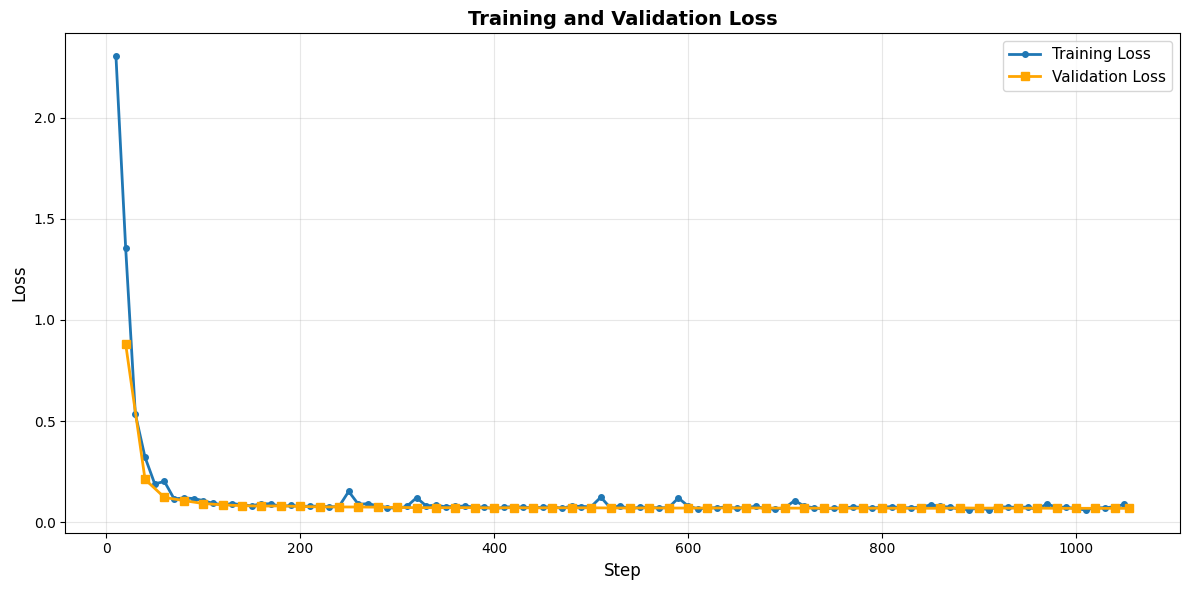


Training Summary:
Initial training loss: 2.3045
Final training loss:   0.0875
Initial validation loss: 0.8812
Final validation loss:   0.0683


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from trainer
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot training loss
if train_logs:
    steps = [x.get('step', i) for i, x in enumerate(train_logs)]
    losses = [x['loss'] for x in train_logs]
    ax.plot(steps, losses, marker='o', label='Training Loss', linewidth=2, markersize=4)

# Plot validation loss
if eval_logs:
    steps = [x.get('step', i) for i, x in enumerate(eval_logs)]
    losses = [x['eval_loss'] for x in eval_logs]
    ax.plot(steps, losses, marker='s', label='Validation Loss', linewidth=2, markersize=6, color='orange')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"Training Summary:")
print(f"{'='*50}")
if train_logs:
    print(f"Initial training loss: {train_logs[0]['loss']:.4f}")
    print(f"Final training loss:   {train_logs[-1]['loss']:.4f}")
if eval_logs:
    print(f"Initial validation loss: {eval_logs[0]['eval_loss']:.4f}")
    print(f"Final validation loss:   {eval_logs[-1]['eval_loss']:.4f}")
print(f"{'='*50}")

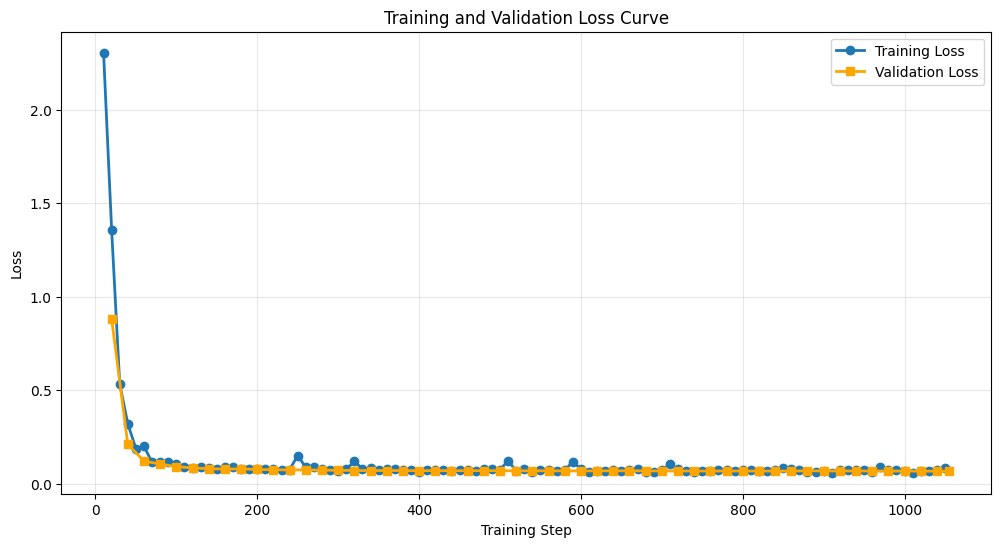

Loss curve saved to ./lora_chiva_finetuned/loss_curve.png


In [13]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(12, 6))

if train_logs:
    steps = [x.get('step', i) for i, x in enumerate(train_logs)]
    losses = [x['loss'] for x in train_logs]
    ax.plot(steps, losses, marker='o', label='Training Loss', linewidth=2)

if eval_logs:
    steps = [x.get('step', i) for i, x in enumerate(eval_logs)]
    losses = [x['eval_loss'] for x in eval_logs]
    ax.plot(steps, losses, marker='s', label='Validation Loss', linewidth=2, color='orange')

ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('./lora_chiva_finetuned/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Loss curve saved to ./lora_chiva_finetuned/loss_curve.png")

In [29]:
# Save the trained model
model.save_pretrained("./lora_chiva_finetuned")
tokenizer.save_pretrained("./lora_chiva_finetuned")
print("✓ Model saved")

✓ Model saved


In [31]:
from peft import PeftModel

BASE_MODEL_ID = 'mistralai/Mistral-7B-Instruct-v0.2'
LORA_PATH = "/home/krish/lora_chiva_finetuned"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
test_tokenizer.pad_token = test_tokenizer.eos_token

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, LORA_PATH)

print("Merging adapter into base model...")
model = model.merge_and_unload()

print("✓ Model merged\n")

# Test
test_prompt = """[INST] Classify CHIVA shunt: EP N1→N2, RP N2→N1. Type? [/INST]"""

inputs = test_tokenizer(test_prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=test_tokenizer.eos_token_id,
    )

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
if "[/INST]" in response:
    response = response.split("[/INST]")[1].strip()

print(f"Response:\n{response}")

# Save merged model
print("\nSaving merged model...")
model.save_pretrained("./lora_chiva_merged")
test_tokenizer.save_pretrained("./lora_chiva_merged")
print("✓ Saved to ./lora_chiva_merged/")

Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [01:03<00:00,  4.59it/s]


Loading LoRA adapter...
Merging adapter into base model...
✓ Model merged

Response:
The CHIVA shunt you described has a counter-directional flow, with the EP (extrahepatic-to-peritoneal) shunt flowing from vein N1 to vein N2, and the RP (peritoneal-to-extrahepatic) shunt flowing from vein N2 to vein N1. This classification is known as a "reverse" or "counter-flow" shunt.

Counter-flow shunts are less common than the more typical forward-flow shunts (EP N1→N3, RP N3→N1), but they can still be effective in managing certain types of portal hypertension. The specific hemodynamic implications of this flow pattern may vary depending on the individual patient's anatomy and physiology.

Overall, the CHIVA shunt you described can be classified as a "reverse" or "counter-flow"

Saving merged model...


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [01:56<00:00, 116.66s/it]


✓ Saved to ./lora_chiva_merged/


In [34]:
# Test prompts
test_prompts = [
    """[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  - Clip 1: EP N1 to N2 (position=0.080)
  - Clip 2: RP N2 to N1 (position=0.300)

Based on the flow patterns, determine the CHIVA shunt type, confidence, and reasoning. [/INST]""",

    """[INST] What are the treatment options for a Type 2A CHIVA shunt with tributary involvement? [/INST]""",

    """[INST] Describe the hemodynamic findings that distinguish Type 1 from Type 2B shunts. [/INST]"""
]

# Generate responses
for i, prompt in enumerate(test_prompts, 1):
    print(f"{'='*80}")
    print(f"TEST {i}")
    print(f"{'='*80}")
    print(f"Prompt: {prompt[:150]}...\n")
    
    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=500,
            do_sample=False,
            temperature=0.7,
            pad_token_id=test_tokenizer.eos_token_id,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract only the response part (after [/INST])
    if "[/INST]" in response:
        response = response.split("[/INST]")[1].strip()
    
    print(f"Response:\n{response}\n")

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEST 1
Prompt: [INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  - Clip 1: EP N1 to N2 (position=0.080)
  - Clip 2: R...

Response:
Based on the provided clips, it is not possible to definitively determine the CHIVA shunt type with high confidence. However, we can make an educated guess based on the information available.

The CHIVA shunt classification system is based on the hemodynamic patterns observed in the hepatic vein and the inferior vena cava (IVC). The specific shunt type depends on the direction and timing of the flow in the hepatic vein and the IVC.

In Clip 1, the flow is from the hepatic vein (N1) to the IVC (N2), with a delay of 0.080 seconds. This suggests a type 1B shunt, which is characterized by a hepatic vein to IVC shunt with a significant delay. However, the absence of a clear reverse flow in Clip 2 makes this classification uncertain.

In Clip 2, the flow is from the IVC (N1) to the hepatic vein (N2), but the positi

In [35]:
print(f"Model device: {next(model.parameters()).device}")
print(f"Model dtype: {next(model.parameters()).dtype}")

Model device: cuda:0
Model dtype: torch.bfloat16


In [37]:
# Test clips in proper format
test_cases = [
    {
        "name": "Type 1 - SFJ Incompetent, GSV Reflux",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.080, "step": "SFJ-ENTRY"},
            {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.250},
        ]
    },
    {
        "name": "Type 2A - Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.200},
            {"flow": "RP", "fromType": "N3", "toType": "N2", "posYRatio": 0.470},
        ]
    },
    {
        "name": "Type 2B - Perforator Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N2", "posYRatio": 0.050, "step": "SFJ-Knee"},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.132},
        ]
    },
    {
        "name": "Type 3 - SFJ Incompetent with Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.050},
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.132},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.212},
        ]
    },
]

# CHIVA rules (embedded in prompt)
CHIVA_RULES = """=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perforator — SFJ REMAINS COMPETENT.

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT → go to Case A or B.
    NO  → SFJ COMPETENT → go to Case C.

Case A — EP N1→N2 EXISTS, NO EP N2→N3:
    If RP N2→N1 present AND no RP at N3 → TYPE 1

Case B — EP N1→N2 EXISTS AND EP N2→N3 EXISTS:
    If RP N3 only, NO RP N2→N1 → TYPE 3
    If RP N3 AND RP N2→N1, no elimination test → UNDETERMINED
    If RP N3 AND RP N2→N1, elimination="Reflux" → TYPE 1+2
    If RP N3 AND RP N2→N1, elimination="No Reflux" → TYPE 3

Case C — NO EP N1→N2 (SFJ COMPETENT):
    If EP N2→N3 present → TYPE 2A
    If EP N2→N2 (perforator) + RP N3 only → TYPE 2B
    If EP N2→N2 (perforator) + RP N3 + RP N2→N1 → TYPE 2C
    If EP N1→N3 + RP N2→N1 → TYPE 4
    If EP N1→N3 + RP N3 return → TYPE 5
    If no RP anywhere → NO SHUNT
"""

def format_clips(clips):
    lines = []
    for i, c in enumerate(clips):
        flow = c.get("flow", "?")
        ft = c.get("fromType", "?")
        tt = c.get("toType", "?")
        y = c.get("posYRatio", 0.0)
        step = c.get("step", "")
        lines.append(f"  Clip {i}: {flow} {ft}→{tt} y={y:.3f}" + (f" [{step}]" if step else ""))
    return "\n".join(lines)

# Test each case
for test_case in test_cases:
    print(f"\n{'='*80}")
    print(f"TEST: {test_case['name']}")
    print(f"{'='*80}")
    
    clips_str = format_clips(test_case['clips'])
    
    prompt = f"""{CHIVA_RULES}

=== ASSESSMENT: Left Leg ({len(test_case['clips'])} clips) ===
{clips_str}

Classify the shunt type based on CHIVA rules.
Output ONLY JSON (no markdown or extra text):
{{"shunt_type": "<type>", "confidence": <0-1>, "reasoning": "<explanation>"}}"""

    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            pad_token_id=test_tokenizer.eos_token_id,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract JSON from response
    if "{" in response:
        json_str = response[response.find("{"):]
        if "}" in json_str:
            json_str = json_str[:json_str.rfind("}")+1]
            try:
                result = json.loads(json_str)
                print(f"Shunt Type: {result.get('shunt_type')}")
                print(f"Confidence: {result.get('confidence', 0):.2f}")
                print(f"Reasoning: {result.get('reasoning')}")
            except:
                print(f"Raw response: {response[:500]}")
    else:
        print(f"Response: {response[:500]}")

print("\n✓ Testing complete!")


TEST: Type 1 - SFJ Incompetent, GSV Reflux
Raw response: === CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood

TEST: Type 2A - Tributary Entry
Raw response: === CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    S

In [41]:
for test_case in test_cases:
    clips_str = format_clips_training(test_case['clips'])
    
    prompt = f"""[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
{clips_str}

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST]"""

    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    print(f"\n{'='*80}")
    print(f"TEST: {test_case['name']}")
    print(f"{'='*80}")
    print("FULL RESPONSE:")
    print(response)  # Print everything
    print()

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 1 - SFJ Incompetent, GSV Reflux
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N1→N2 (position=0.080)
  • Clip 2: RP N2→N1 (position=0.250)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the provided clips, I would classify this as a Type 1B (reciprocal) CHIVA shunt. Here's my reasoning:

1. Flow patterns:
   - Clip 1 (EP): The early diastolic flow from chamber N1 to N2 is prominent and unidirectional, indicating a low-resistance communication between the chambers.
   - Clip 2 (RP): The late diastolic flow from chamber N2 to N1 is also prominent and unidirectional, indicating a reciprocal communication between the chambers.

2. Anatomical relationships:
   - The anatomical relationship between the chambers is important in determining the shunt type. In this case, the anatomical relationship 

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 2A - Tributary Entry
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N2→N3 (position=0.200)
  • Clip 2: RP N3→N2 (position=0.470)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the provided clips, the CHIVA shunt type is Type 1.

Reasoning:
In Type 1 shunts, there is a direct communication between the portal vein (PV) and the hepatic veins (HV) without passing through the liver sinusoids. This is characterized by a flow reversal in the hepatic vein (HV) relative to the portal vein (PV) flow.

In Clip 1, we see a flow from the portal vein (N2) to the hepatic vein (N3), which is consistent with a Type 1 shunt. The position of this flow is around 0.200 seconds.

In Clip 2, we see a flow from the hepatic vein (N3) to the portal vein (N2), which is also consistent with a Type 1 shunt. The



[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 2B - Perforator Entry
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N2→N2 (position=0.050)
  • Clip 2: RP N3→N1 (position=0.132)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the given clips, the CHIVA shunt type can be determined as follows:

Type: Type 1

Confidence level: High

Reasoning:
In Clip 1, the flow is from the early venous system (EP N2) to the same level (N2), indicating a normal flow pattern with no significant reflux.

In Clip 2, the flow is from the late venous system (RP N3) to an earlier level (N1), which is the defining characteristic of Type 1 CHIVA shunt. This indicates a direct communication between the late and early venous systems, allowing for potential reflux and inefficient blood flow.

Therefore, the confidence level is high, and the classification is Type 1 CH

Further Testing

In [2]:
import os
os.environ['TORCH_CUDA_ARCH_LIST'] = "12.0"
os.environ['FORCE_CUDA'] = "1"

import torch

print("✓ All libraries imported successfully")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All libraries imported successfully
✓ CUDA available: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM available: 34.2 GB


In [3]:
import json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType
import warnings
warnings.filterwarnings('ignore')

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load WITHOUT merging
base_model = AutoModelForCausalLM.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2',
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')
test_tokenizer.pad_token = test_tokenizer.eos_token

# Load LoRA WITHOUT merging
from peft import PeftModel
model_with_lora = PeftModel.from_pretrained(base_model, "/home/krish/lora_chiva_finetuned")
model_with_lora.eval()

# Test
prompt = """[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST]"""
inputs = test_tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model_with_lora.generate(**inputs, max_new_tokens=150, do_sample=False)

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
print("WITH LoRA (not merged):")
print(response)

# Also test base model alone
with torch.no_grad():
    outputs_base = base_model.generate(**inputs, max_new_tokens=150, do_sample=False)

response_base = test_tokenizer.decode(outputs_base[0], skip_special_tokens=True)
print("\n\nBASE MODEL ONLY:")
print(response_base)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:07<00:00, 37.87it/s]
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


WITH LoRA (not merged):
[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST] Based on the given timestamps, I assume you are referring to the transition between Edit Point (EP) N1 and N2, and the Reverse Edit Point (RP) N2 and N1, in video editing.

To classify these edit points, we need to analyze the type of transition that occurs between the clips.

Clip 1: EP N1→N2 (0.080)
This is a forward edit point, indicating the start of a new clip or sequence. The 0.080 second duration suggests a relatively smooth transition, such as a crossfade or a cut.

Clip 2: RP N2→N1 (0.2


BASE MODEL ONLY:
[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST] Based on the given timestamps, I assume you are referring to the transition between Edit Point (EP) N1 and N2, and the Reverse Edit Point (RP) N2 and N1, in video editing.

To classify these edit points, we need to analyze the type of transition that occurs between the clips.

Clip 1: EP N1→N2 (0.080)
T

In [6]:
test_cases = [
    {
        "name": "Type 1 - SFJ Incompetent, GSV Reflux",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.080, "step": "SFJ-ENTRY"},
            {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.250},
        ]
    },
    {
        "name": "Type 2A - Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.200},
            {"flow": "RP", "fromType": "N3", "toType": "N2", "posYRatio": 0.470},
        ]
    },
    {
        "name": "Type 2B - Perforator Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N2", "posYRatio": 0.050, "step": "SFJ-Knee"},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.132},
        ]
    },
    {
        "name": "Type 3 - SFJ Incompetent with Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.050},
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.132},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.212},
        ]
    },
]

In [7]:
# Load WITHOUT merging
base_model = AutoModelForCausalLM.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2',
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')
test_tokenizer.pad_token = test_tokenizer.eos_token

# Load LoRA WITHOUT merging
from peft import PeftModel
model_with_lora = PeftModel.from_pretrained(base_model, "/home/krish/lora_chiva_finetuned")
model_with_lora.eval()

Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:07<00:00, 37.50it/s]


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [10]:
# Test
prompt = """[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST]"""
inputs = test_tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model_with_lora.generate(**inputs, max_new_tokens=150, do_sample=False)

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
print("WITH LoRA (not merged):")
print(response)

# Also test base model alone
with torch.no_grad():
    outputs_base = base_model.generate(**inputs, max_new_tokens=150, do_sample=False)

response_base = test_tokenizer.decode(outputs_base[0], skip_special_tokens=True)
print("\n\nBASE MODEL ONLY:")
print(response_base)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


WITH LoRA (not merged):
[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST] Porto-systemic shunt


BASE MODEL ONLY:
[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST] Porto-systemic shunt


**Finetuning and Testing Qwen3-4B**

In [1]:
import torch
import json
from pathlib import Path
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful")
print(f"✓ CUDA: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful
✓ CUDA: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM: 34.2 GB


In [18]:
# Paths
TRAIN_FILE = Path('training_data.jsonl')
VAL_FILE = Path('validation_data.jsonl')
OUTPUT_DIR = Path('./qwen25_chiva_finetuned')

# Model
BASE_MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
MAX_SEQ_LENGTH = 1024 #2048

# Training hyperparameters (from script2)
NUM_EPOCHS = 3
#BATCH_SIZE = 4  # RTX 5090 handles 4 comfortably with 4-bit
#GRAD_ACCUM_STEPS = 4  # effective batch = 16
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.05
LR_SCHEDULER = 'cosine'
SAVE_STEPS = 500

# LoRA config (from script2)
LORA_R = 32
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = 'all-linear'
USE_DORA = True
USE_RSLORA = True
LORA_INIT = 'gaussian'

# Optimizer
OPTIM = 'paged_adamw_32bit'

print('Config loaded.')
print(f'  r={LORA_R}, alpha={LORA_ALPHA}, init={LORA_INIT}, DoRA={USE_DORA}, rsLoRA={USE_RSLORA}')
print(f'  Target modules: {LORA_TARGET}')
print(f'  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}')

Config loaded.
  r=32, alpha=32, init=gaussian, DoRA=True, rsLoRA=True
  Target modules: all-linear
  Effective batch: 16


In [19]:
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_pairs = load_jsonl(TRAIN_FILE)
val_pairs = load_jsonl(VAL_FILE)

print(f"✓ Loaded {len(train_pairs)} training pairs")
print(f"✓ Loaded {len(val_pairs)} validation pairs")

# Show distribution
train_types = {}
for pair in train_pairs:
    ptype = pair.get('type', 'unknown')
    train_types[ptype] = train_types.get(ptype, 0) + 1

print("\nTraining data distribution:")
for ptype, count in sorted(train_types.items()):
    print(f"  {ptype}: {count}")

✓ Loaded 4508 training pairs
✓ Loaded 501 validation pairs

Training data distribution:
  unknown: 4508


In [20]:
train_pairs[0]

{'text': '<s>[INST] You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.\n\nDescribe the key points from the following passage relevant to duplex ultrasound practice:\n\nidea of \nimplanting valves via the endovascular approach was first done using an external jugular vein \nwith a competent valve mounted in a Z-stent (Cook Medical, Bloomington, IN) that was deployed \nin either the external (n = 4) or common iliac vein (n = 1) in dogs.51 One of five valves implanted \nwas patent, competent, and with minimal inflammatory surrounding reaction. Interestingly, the \nnormal-appearing valve was deployed in the common iliac vein, which has a higher flow pattern.51 \nDifferent valve materials varying from glutaraldehyde-preserved bovine vein to a collagen tissue \nmodel of porcine small intestine submucosa (SIS) have been initially studied in animal 

In [21]:
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_data = load_jsonl(TRAIN_FILE)
val_data = load_jsonl(VAL_FILE)

print(f"✓ Loaded {len(train_data)} training examples")
print(f"✓ Loaded {len(val_data)} validation examples")

✓ Loaded 4508 training examples
✓ Loaded 501 validation examples


In [22]:
def clean_text(item):
    text = item.get('text', '')
    # Remove [INST] and [/INST] tags
    text = text.replace('<s>[INST]', '').replace('[/INST]', '').replace('</s>', '').strip()
    return text

train_texts = [clean_text(item) for item in train_data]
val_texts = [clean_text(item) for item in val_data]

print(f"✓ Cleaned {len(train_texts)} training texts")
print(f"✓ Cleaned {len(val_texts)} validation texts")
print(f"\nSample:\n{train_texts[0][:300]}...")

✓ Cleaned 4508 training texts
✓ Cleaned 501 validation texts

Sample:
You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.

Describe the key points from the following passage relevant to duplex ultrasound practice:

idea of 
...


In [23]:
#! pip install huggingface-hub

In [24]:
#!hf download Qwen/Qwen2.5-7B-Instruct --local-dir ./Qwen25-7B

In [25]:
BASE_MODEL_ID = '/home/krish/Qwen25-7B'
print(f"Loading model from {BASE_MODEL_ID}...")

# 4-bit quantization config (from script2)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model loaded successfully")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Model device: {next(model.parameters()).device}")
print(f"✓ Model dtype: {next(model.parameters()).dtype}")

Loading model from /home/krish/Qwen25-7B...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:03<00:00, 92.39it/s]


✓ Model loaded successfully
✓ Total parameters: 4,352,972,288
✓ Model device: cuda:0
✓ Model dtype: torch.bfloat16


In [26]:
print("Preparing model for 4-bit training...")
model = prepare_model_for_kbit_training(model)

print("Configuring LoRA with DoRA + rsLoRA + PiSSA...")
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    use_dora=USE_DORA,
    use_rslora=USE_RSLORA,
    init_lora_weights=LORA_INIT,
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
pct = 100 * trainable_params / total_params

print(f"✓ LoRA configured with advanced methods")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Total parameters: {total_params:,}")
print(f"  Percentage trainable: {pct:.4f}%")
print(f"  rsLoRA effective scale: {LORA_ALPHA / LORA_R**0.5:.4f}")

Preparing model for 4-bit training...
Configuring LoRA with DoRA + rsLoRA + PiSSA...
✓ LoRA configured with advanced methods
  Trainable parameters: 82,130,944
  Total parameters: 4,435,103,232
  Percentage trainable: 1.8518%
  rsLoRA effective scale: 5.6569


In [27]:
from datasets import Dataset 
def tokenize_function(examples):
    outputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding="max_length",
    )
    outputs["labels"] = outputs["input_ids"].copy()
    return outputs

print("Creating training dataset...")
train_dataset = Dataset.from_dict({"text": train_texts})
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing training data",
    batch_size=32
)

print("Creating validation dataset...")
val_dataset = Dataset.from_dict({"text": val_texts})
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing validation data",
    batch_size=32
)

print(f"✓ Training: {len(train_dataset)}")
print(f"✓ Validation: {len(val_dataset)}")

Creating training dataset...


Tokenizing training data: 100%|████████████████████████████████████████████| 4508/4508 [00:01<00:00, 2796.23 examples/s]


Creating validation dataset...


Tokenizing validation data: 100%|████████████████████████████████████████████| 501/501 [00:00<00:00, 2761.73 examples/s]

✓ Training: 4508
✓ Validation: 501


In [28]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=True,
    optim=OPTIM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    fp16=False,
    bf16=False,  # Handled by BitsAndBytesConfig
    save_steps=SAVE_STEPS,
    eval_steps=SAVE_STEPS,
    eval_strategy='steps',
    save_total_limit=3,
    logging_steps=10,
    logging_dir='./logs',
    report_to=['tensorboard'],  # Set to ['wandb'] if you want W&B
    remove_unused_columns=False,
)

print(f"✓ Training arguments configured")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE} (cosine scheduler)")
print(f"  Optimizer: {OPTIM}")
print(f"  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

eff_batch = BATCH_SIZE * GRAD_ACCUM_STEPS
steps_per_epoch = len(train_dataset) // eff_batch
print(f"  Steps/epoch: ~{steps_per_epoch}")
print(f"  Total steps: ~{steps_per_epoch * NUM_EPOCHS}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Training arguments configured
  Epochs: 3
  Learning rate: 0.0002 (cosine scheduler)
  Optimizer: paged_adamw_32bit
  Effective batch: 16
  Steps/epoch: ~281
  Total steps: ~843


In [29]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("✓ Trainer created and ready")

✓ Trainer created and ready


In [30]:
old_code = """
print("=" * 80)
print("Starting training with script2 strategy (DoRA + rsLoRA + PiSSA + 4-bit QLoRA)")
print("=" * 80)
print()

train_result = trainer.train()

print()
print("=" * 80)
print("Training complete!")
print("=" * 80)
print(f"Final training loss: {train_result.training_loss:.4f}")

# Save the model
print(f"\nSaving LoRA adapter to {OUTPUT_DIR}...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

output_path = Path(OUTPUT_DIR)
saved_files = list(output_path.glob("*"))
print(f"✓ Saved {len(saved_files)} files:")
for f in saved_files:
    if f.is_file():
        size = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name} ({size:.2f} MB)")

print(f"\n✓ Model ready at: {OUTPUT_DIR}/")"""

In [31]:
%load_ext tensorboard
%tensorboard --logdir ./logs

In [32]:
 %reload_ext tensorboard

In [33]:
print("Train dataset structure:")
print(train_dataset[0].keys())
print(f"Sample input_ids length: {len(train_dataset[0]['input_ids'])}")
print(f"Sample labels length: {len(train_dataset[0]['labels'])}")
print(f"Sample attention_mask: {len(train_dataset[0]['attention_mask'])}")

print("\nDataset stats:")
print(f"Total examples: {len(train_dataset)}")
print(f"Input IDs sample: {train_dataset[0]['input_ids'][:10]}")

Train dataset structure:
dict_keys(['input_ids', 'attention_mask', 'labels'])
Sample input_ids length: 1024
Sample labels length: 1024
Sample attention_mask: 1024

Dataset stats:
Total examples: 4508
Input IDs sample: [2610, 525, 264, 6457, 6203, 3281, 3791, 304, 11208, 782]


In [ ]:
print("=" * 80)
print("Starting training with script2 strategy")
print("=" * 80)

train_result = trainer.train()

print()
print("=" * 80)
print("Training complete!")
print("=" * 80)
print(f"Final loss: {train_result.training_loss:.4f}")

# Save
model.save_pretrained('./qwen25_chiva_finetuned')
tokenizer.save_pretrained('./qwen25_chiva_finetuned')
print(f"✓ Model saved to ./qwen25_chiva_finetuned/")

Starting training with script2 strategy


Step,Training Loss,Validation Loss
